## I. Camera Geometric Calibration 

This calibration is performed using pyfai library. It is used to generate the following file(s):
- a *.poni file that contains all required information for further data processing
- an optional mask file (*.edf) to mask undiserable pixels

Note that beam center is automatically recalibrated before image processing. Distance and camera roation angles are assumed constant.

**/!\ Remember to save mask (.edf) and .poni files from pyFAI-calibration tool.**

In [2]:
from epdfsuite.calibration import perform_geometric_calibration

datapath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/Aucal/OneView/'
sample_diff_calib = datapath + "500X_OneView_200kV_2439.dm4" # Au calibrant diffraction data
# path to Au cif file used for calibration
cif_file = "/home-local/ratel-ra/Documents/CIF_database/Au_fixed.cif"
mtf_file = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf/oneview_2k_slanted.mtf' # optionnal

perform_geometric_calibration(
    image_file=sample_diff_calib,
    cif_file = cif_file,
    mtf_file=mtf_file) # optional

## II. Camera Modulation Transfer Function (MTF) 


The camera MTF is estimated based on the slanted edge method.
In practice, an image of the beamstop is acquired.
Here are the main steps involved in the MTF determination:
- create mask on image to select ROI (select on edge of the beamstop)
- calculate MTF based on the slanted edge method

**Draw image mask**

In [1]:
from epdfsuite.utilities import draw_mask
beamstop_image = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/20kX_OneView_200kV_2433.dm4'
draw_mask(beamstop_image)

## Do not forget to save mask after editing in pyFAI-drawmask

Loaded file: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/20kX_OneView_200kV_2433.dm4
Sample information:
  binning: 1
  description: Gatan OneView sCMOS camera
  image_height: 4096
  image_width: 4096
  pixel_size: 15
  camera_type: OneView
  camera_title: 20kX_OneView_200kV_2433
  wavelength: 0.025079340450548007
  exposure_time: 4.0


Matplotlib already loaded with backend `Qt5Agg`, setting its backend to `QtAgg` may not work!


Your mask-file will be saved into /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/20kX_OneView_200kV_2433-mask.edf
Selected 0 datapoints on file /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/20kX_OneView_200kV_2433.edf
On File: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/20kX_OneView_200kV_2433.edf,	 mean= nan 	 std= nan


  print("On File: %s,\t mean= %s \t std= %s" % (datafile, data.mean(), data.std()))

  ret = ret.dtype.type(ret / rcount)

  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

  arrmean = um.true_divide(arrmean, div, out=arrmean,

  ret = ret.dtype.type(ret / rcount)



**Compute MTF using slanted edge method**

[INFO] Edge detected: angle=17.95°, rho=-670.0 px, x_edge≈986.9 px
[INFO] Effective ROI half-width: 10.6 px (left=984.0, right=10.6)
[INFO] erf fit: x0=1.77 px, sigma=1.036 px
MTF50: 0.360 f_Nyq  (0.012 µm⁻¹)
MTF20: 0.559 f_Nyq  (0.019 µm⁻¹)
Signal patch (background, eroded 5px): 5282 pixels, Noise patch (beamstop, eroded 5px): 232814 pixels


/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/utilities.py:536: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(mask_noise_disp, levels=[0.5], colors='red', linewidths=2, linestyles='-', label='Noise (beamstop)')
/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/utilities.py:540: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(mask_signal_disp, levels=[0.5], colors='blue', linewidths=1, linestyles='--', label='Signal (background)')


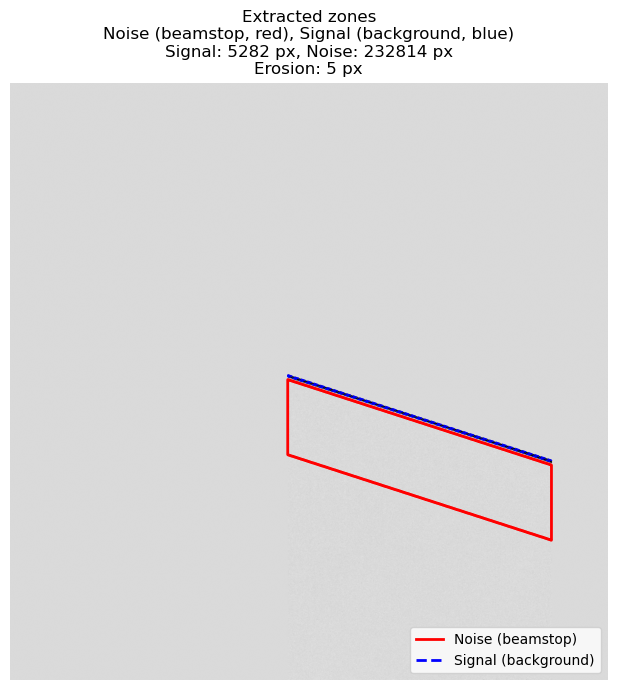

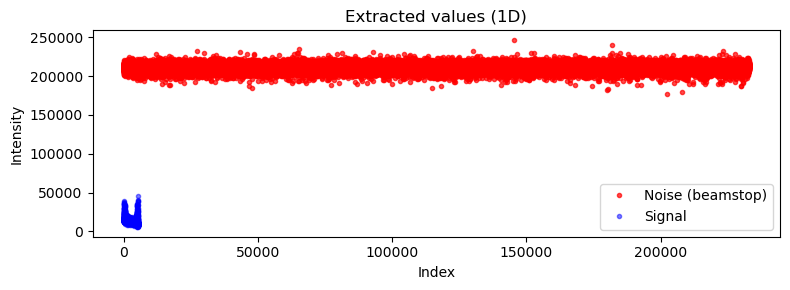

Estimated Wiener epsilon (noise/signal ratio): 0.1042


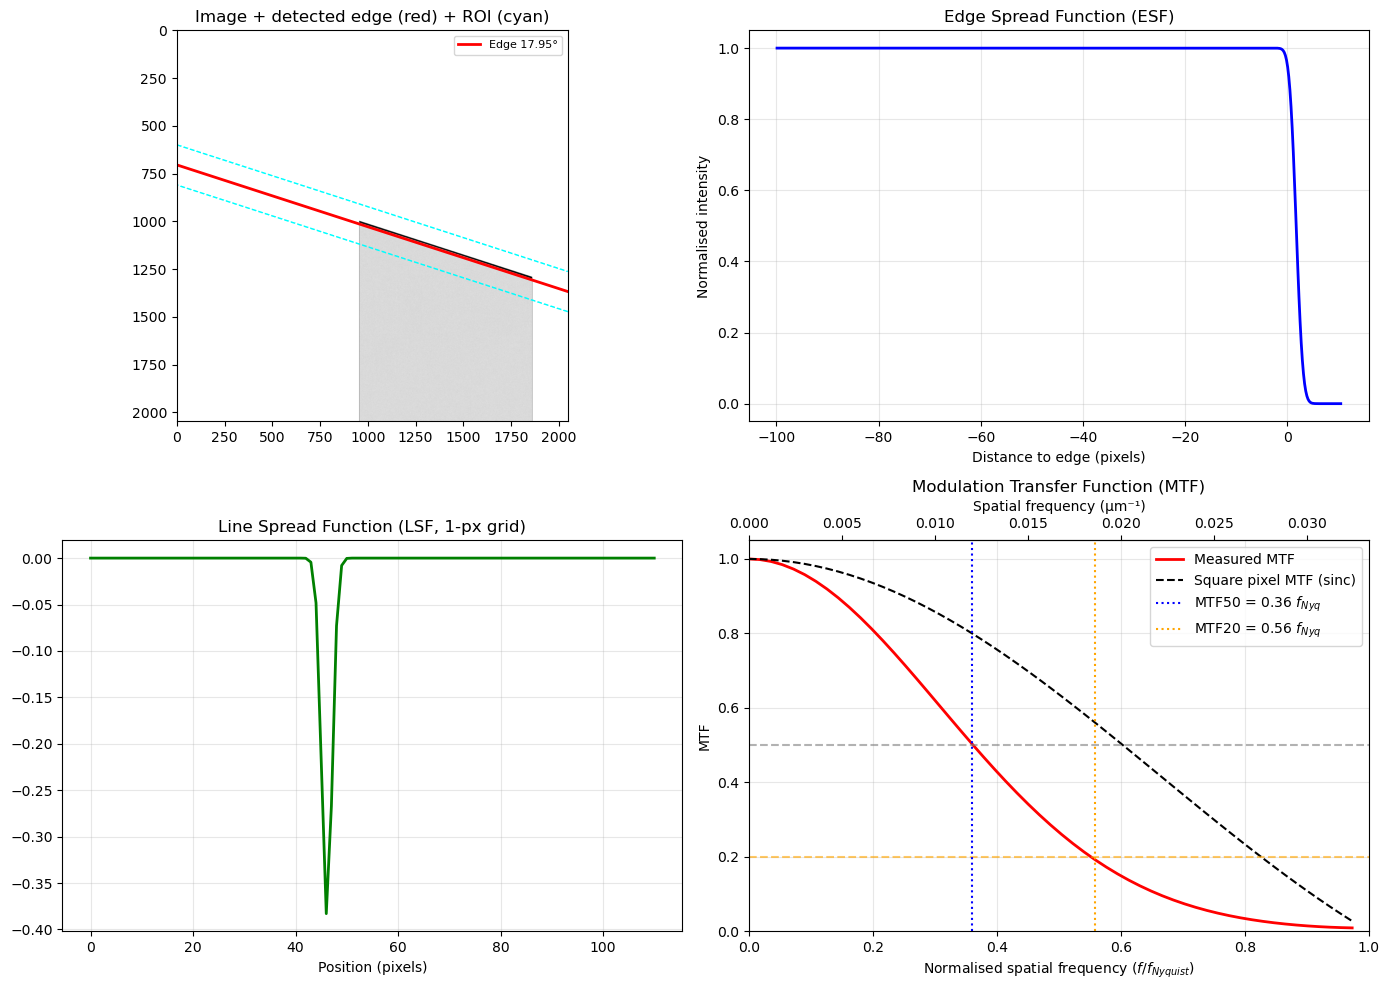

MTF saved: ./oneview_2k_slanted.mtf


In [2]:
from epdfsuite.utilities import compute_mtf_slanted_edge

outputfile='./oneview_2k_slanted.mtf'
maskfile = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/mask_oneview_2k.edf'
freq, mtf = compute_mtf_slanted_edge(
    beamstop_image,
    mask=maskfile,
    roi_half_width=100,
    outputfile=outputfile) 